# 1. Importing modules and functions

In [129]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from molvs import standardize_smiles
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from catboost import CatBoostRegressor
from sklearn.svm import SVR
from sklearn.model_selection import permutation_test_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn import metrics
from sklearn.metrics import pairwise_distances
import joblib
import pickle
from numpy import savetxt
from padelpy import from_sdf
import shap
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

In [3]:
import glob
xml_files = glob.glob("fingerprints_xml/*.xml")
xml_files.sort()
xml_files

['fingerprints_xml\\AtomPairs2DFingerprintCount.xml',
 'fingerprints_xml\\AtomPairs2DFingerprinter.xml',
 'fingerprints_xml\\EStateFingerprinter.xml',
 'fingerprints_xml\\ExtendedFingerprinter.xml',
 'fingerprints_xml\\Fingerprinter.xml',
 'fingerprints_xml\\GraphOnlyFingerprinter.xml',
 'fingerprints_xml\\KlekotaRothFingerprintCount.xml',
 'fingerprints_xml\\KlekotaRothFingerprinter.xml',
 'fingerprints_xml\\MACCSFingerprinter.xml',
 'fingerprints_xml\\PubchemFingerprinter.xml',
 'fingerprints_xml\\SubstructureFingerprintCount.xml',
 'fingerprints_xml\\SubstructureFingerprinter.xml']

In [4]:
FP_list = ['AtomPairs2DCount',
 'AtomPairs2D',
 'EState',
 'CDKextended',
 'CDK',
 'CDKgraphonly',
 'KlekotaRothCount',
 'KlekotaRoth',
 'MACCS',
 'PubChem',
 'SubstructureCount',
 'Substructure']

In [5]:
fp = dict(zip(FP_list, xml_files))
fp

{'AtomPairs2DCount': 'fingerprints_xml\\AtomPairs2DFingerprintCount.xml',
 'AtomPairs2D': 'fingerprints_xml\\AtomPairs2DFingerprinter.xml',
 'EState': 'fingerprints_xml\\EStateFingerprinter.xml',
 'CDKextended': 'fingerprints_xml\\ExtendedFingerprinter.xml',
 'CDK': 'fingerprints_xml\\Fingerprinter.xml',
 'CDKgraphonly': 'fingerprints_xml\\GraphOnlyFingerprinter.xml',
 'KlekotaRothCount': 'fingerprints_xml\\KlekotaRothFingerprintCount.xml',
 'KlekotaRoth': 'fingerprints_xml\\KlekotaRothFingerprinter.xml',
 'MACCS': 'fingerprints_xml\\MACCSFingerprinter.xml',
 'PubChem': 'fingerprints_xml\\PubchemFingerprinter.xml',
 'SubstructureCount': 'fingerprints_xml\\SubstructureFingerprintCount.xml',
 'Substructure': 'fingerprints_xml\\SubstructureFingerprinter.xml'}

# 2.Data entry and curation work set

In [6]:
uploaded_file_ws="datasets/HDAC8_work.sdf"
supplier_ws = Chem.ForwardSDMolSupplier(uploaded_file_ws,sanitize=False)
failed_mols_ws = []
all_mols_ws =[]
wrong_structure_ws=[]
wrong_smiles_ws=[]
y_tr = []
y_bad_index=[]

for i, m in enumerate(supplier_ws):
    structure = Chem.Mol(m)
    all_mols_ws.append(structure)
    y_tr.append(m.GetProp("pchembl_value_mean"))
    try:
        Chem.SanitizeMol(structure)
    except:
        failed_mols_ws.append(m)
        wrong_smiles_ws.append(Chem.MolToSmiles(m))
        wrong_structure_ws.append(str(i+1))
        y_bad_index.append(i)
print('Original data: ', len(all_mols_ws), 'molecules')
print('Failed data: ', len(failed_mols_ws), 'molecules')
number_ws =[]
for i in range(len(failed_mols_ws)):
        number_ws.append(str(i+1))
bad_molecules_ws = pd.DataFrame({'No. failed molecule in original set': wrong_structure_ws, 'SMILES of wrong structure: ': wrong_smiles_ws, 'No.': number_ws}, index=None)
bad_molecules_ws = bad_molecules_ws.set_index('No.')
bad_molecules_ws

Original data:  2210 molecules
Failed data:  0 molecules


,No. failed molecule in original set,SMILES of wrong structure:
No.,,


deleting activity values for substances with incorrect structure

In [7]:
y_tr[:] = [x for i,x in enumerate(y_tr) if i not in y_bad_index]

In [8]:
len(y_tr)

2210

# 3.Standardization SDF file for work set

In [9]:
all_mols_ws[:] = [x for i,x in enumerate(all_mols_ws) if i not in y_bad_index] 
records = []
for i in range(len(all_mols_ws)):
    record = Chem.MolToSmiles(all_mols_ws[i])
    records.append(record)

moldf_ws = []
for i,record in enumerate(records):
    standard_record = standardize_smiles(record)
    m = Chem.MolFromSmiles(standard_record)
    moldf_ws.append(m)
    
print('Kept data: ', len(moldf_ws), 'molecules')

Kept data:  2210 molecules


In [10]:
records_ws = []
for i in range(len(moldf_ws)):
    record = Chem.MolToSmiles(moldf_ws[i])
    records_ws.append(record)

In [11]:
df = pd.DataFrame(records_ws, columns=["Smiles"])
df.to_csv('datasets/molecule_ws.smi', sep=',', index=False, header=False)

# 4.Data entry and curation test set

In [12]:
uploaded_file_ts="datasets/HDAC8_test.sdf"
supplier_ts = Chem.ForwardSDMolSupplier(uploaded_file_ts,sanitize=False)
failed_mols_ts = []
all_mols_ts =[]
wrong_structure_ts=[]
wrong_smiles_ts=[]
y_ts = []
y_bad_index=[]
for i, m in enumerate(supplier_ts):
    structure = Chem.Mol(m)
    all_mols_ts.append(structure)
    y_ts.append(m.GetProp("pchembl_value_mean"))
    try:
        Chem.SanitizeMol(structure)
    except:
        failed_mols_ts.append(m)
        wrong_smiles_ts.append(Chem.MolToSmiles(m))
        wrong_structure_ts.append(str(i+1))
        y_bad_index.append(i)
print('Original data: ', len(all_mols_ts), 'molecules')
print('Failed data: ', len(failed_mols_ts), 'molecules')
number_ts =[]
for i in range(len(failed_mols_ts)):
        number_ts.append(str(i+1))
bad_molecules_ts = pd.DataFrame({'No. failed molecule in original set': wrong_structure_ts, 'SMILES of wrong structure: ': wrong_smiles_ts, 'No.': number_ts}, index=None)
bad_molecules_ts = bad_molecules_ts.set_index('No.')
bad_molecules_ts

Original data:  553 molecules
Failed data:  0 molecules


,No. failed molecule in original set,SMILES of wrong structure:
No.,,


deleting activity values for substances with incorrect structure

In [13]:
y_ts[:] = [x for i,x in enumerate(y_ts) if i not in y_bad_index]

In [14]:
len(y_ts)

553

# 5.Standardization SDF file for test set

In [15]:
all_mols_ts[:] = [x for i,x in enumerate(all_mols_ts) if i not in y_bad_index] 
records = []
for i in range(len(all_mols_ts)):
    record = Chem.MolToSmiles(all_mols_ts[i])
    records.append(record)

moldf_ts = []
for i,record in enumerate(records):
    standard_record = standardize_smiles(record)
    m = Chem.MolFromSmiles(standard_record)
    moldf_ts.append(m)
    
print('Kept data: ', len(moldf_ts), 'molecules')

Kept data:  553 molecules


In [16]:
records_ts = []
for i in range(len(moldf_ts)):
    record = Chem.MolToSmiles(moldf_ts[i])
    records_ts.append(record)

In [16]:
df_ts = pd.DataFrame(records_ts, columns=["Smiles"])
df_ts.to_csv('datasets/molecule_ts.smi', sep=',', index=False, header=False)

# 6.Descriptor calculation for work set

In [17]:
fp

{'AtomPairs2DCount': 'fingerprints_xml\\AtomPairs2DFingerprintCount.xml',
 'AtomPairs2D': 'fingerprints_xml\\AtomPairs2DFingerprinter.xml',
 'EState': 'fingerprints_xml\\EStateFingerprinter.xml',
 'CDKextended': 'fingerprints_xml\\ExtendedFingerprinter.xml',
 'CDK': 'fingerprints_xml\\Fingerprinter.xml',
 'CDKgraphonly': 'fingerprints_xml\\GraphOnlyFingerprinter.xml',
 'KlekotaRothCount': 'fingerprints_xml\\KlekotaRothFingerprintCount.xml',
 'KlekotaRoth': 'fingerprints_xml\\KlekotaRothFingerprinter.xml',
 'MACCS': 'fingerprints_xml\\MACCSFingerprinter.xml',
 'PubChem': 'fingerprints_xml\\PubchemFingerprinter.xml',
 'SubstructureCount': 'fingerprints_xml\\SubstructureFingerprintCount.xml',
 'Substructure': 'fingerprints_xml\\SubstructureFingerprinter.xml'}

### PubChem FPs

In [18]:
from padelpy import padeldescriptor

fingerprint = 'PubChem'

fingerprint_output_file = ''.join([fingerprint,'.csv']) 
fingerprint_descriptortypes = fp[fingerprint]

padeldescriptor(mol_dir='datasets/molecule_ws.smi', 
                d_file=fingerprint_output_file, 
                descriptortypes= fingerprint_descriptortypes,
                detectaromaticity=True,
                standardizenitro=True,
                standardizetautomers=True,
                threads=2,
                removesalt=True,
                log=True,
                fingerprints=True)

In [17]:
descriptors_PubChem = pd.read_csv('PubChem.csv')

In [18]:
descriptors_PubChem

,Name,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,AUTOGEN_molecule_ws_1,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,AUTOGEN_molecule_ws_2,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,AUTOGEN_molecule_ws_3,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,AUTOGEN_molecule_ws_4,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,AUTOGEN_molecule_ws_5,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205,AUTOGEN_molecule_ws_2206,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2206,AUTOGEN_molecule_ws_2207,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2207,AUTOGEN_molecule_ws_2208,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2208,AUTOGEN_molecule_ws_2209,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
descriptors_ws = descriptors_PubChem.drop('Name', axis=1)

In [22]:
descriptors_ws[descriptors_ws['PubchemFP699']==1]

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
1,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
13,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
35,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
37,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
60,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2197,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2198,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2199,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2202,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [20]:
x_tr = np.array(descriptors_ws, dtype=np.float32)
y_tr = np.array(y_tr, dtype=np.float32)

In [24]:
savetxt('Models/Padels/x_tr_PubChem.csv', x_tr, delimiter=',')

In [21]:
x_tr.shape

(2210, 881)

# 7.Descriptor calculation for test set

In [26]:
from padelpy import padeldescriptor

fingerprint = 'PubChem'

fingerprint_output_file = ''.join([fingerprint,'_ts.csv']) #PubChem.csv
fingerprint_descriptortypes = fp[fingerprint]

padeldescriptor(mol_dir='datasets/molecule_ts.smi', 
                d_file=fingerprint_output_file, #'PubChem.csv'
                #descriptortypes='PubChem.xml', 
                descriptortypes= fingerprint_descriptortypes,
                detectaromaticity=True,
                standardizenitro=True,
                standardizetautomers=True,
                threads=2,
                removesalt=True,
                log=False,
                fingerprints=True)

In [170]:
descriptors_PubChem_ts = pd.read_csv('PubChem_ts.csv')

In [171]:
x_ts = descriptors_PubChem_ts.drop('Name', axis=1)

In [172]:
desc_ts=x_ts

In [173]:
x_ts.shape

(553, 881)

 # BASELINE GradientBoostingRegressor

In [32]:
seed = 42

In [33]:
cv=KFold(n_splits=5, random_state=seed, shuffle=True)

In [33]:
%%time
model = CatBoostRegressor()
parameters = {'depth' : [6,8,10],
              'learning_rate' : [0.01, 0.05, 0.1],
              'iterations'    : [100,500, 1000]
              }

grid = GridSearchCV(estimator=model, param_grid = parameters, n_jobs=-1, cv = cv)
grid.fit(x_tr, y_tr, verbose=False)

CPU times: total: 24min 45s
Wall time: 42min 16s


,estimator,CatBoostRegre...nction='RMSE')
,param_grid,"{'depth': [6, 8, ...], 'iterations': [100, 500, ...], 'learning_rate': [0.01, 0.05, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False


In [34]:
best_CatBR = grid.best_estimator_

In [35]:
grid.best_params_

{'depth': 10, 'iterations': 1000, 'learning_rate': 0.05}

In [29]:
y_pred_ws_GBR = best_CatBR.predict(x_tr)

In [30]:
R2_WS = round(r2_score(y_tr, y_pred_ws_GBR), 2)
R2_WS

0.93

In [31]:
RMSE_WS=float(round(np.sqrt(mean_squared_error(y_tr, y_pred_ws_GBR)), 2))
RMSE_WS

0.22

In [36]:
params={'verbose': False}

In [37]:
%%time
y_pred_CV_CatBR = cross_val_predict(best_CatBR, x_tr, y_tr, cv=cv, params=params)

CPU times: total: 2h 2min 30s
Wall time: 9min 5s


In [38]:
Q2_CV = round(r2_score(y_tr, y_pred_CV_CatBR), 2)
Q2_CV

0.53

In [39]:
RMSE_CV=round(np.sqrt(mean_squared_error(y_tr, y_pred_CV_CatBR)), 2)
RMSE_CV

np.float64(0.58)

In [34]:
y_pred_GBR = best_CatBR.predict(desc_ts)

In [35]:
Q2_TS = round(r2_score(y_ts, y_pred_GBR), 2)
Q2_TS

0.58

In [36]:
RMSE_TS=float(round(np.sqrt(mean_squared_error(y_ts, y_pred_GBR)), 2))
RMSE_TS

0.55

save the model to disk

In [43]:
pickle.dump(best_CatBR, open('Models/Padels/CatBoost_PubChem.pkl', 'wb'))

load the model from disk

In [26]:
best_CatBR = pickle.load(open('Models/Padels/CatBoost_PubChem.pkl', 'rb'))

# Calculate Feature Importance

In [37]:
data = pd.DataFrame({'feature_importance': best_CatBR.get_feature_importance(), 
              'feature_names': descriptors_ws.columns}).sort_values(by=['feature_importance'], 
                                                       ascending=False)

<Axes: ylabel='feature_names'>

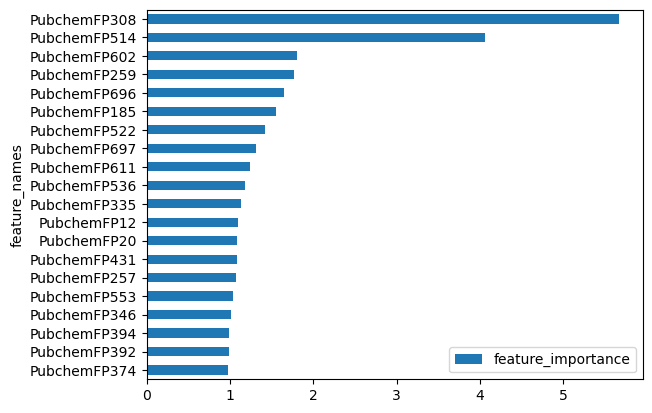

In [38]:
data[:20].sort_values(by=['feature_importance'], ascending=True).plot.barh(x='feature_names', y='feature_importance')

In [39]:
import shap

In [40]:
explainer = shap.Explainer(best_CatBR)

In [41]:
shap_values = explainer(descriptors_ws)

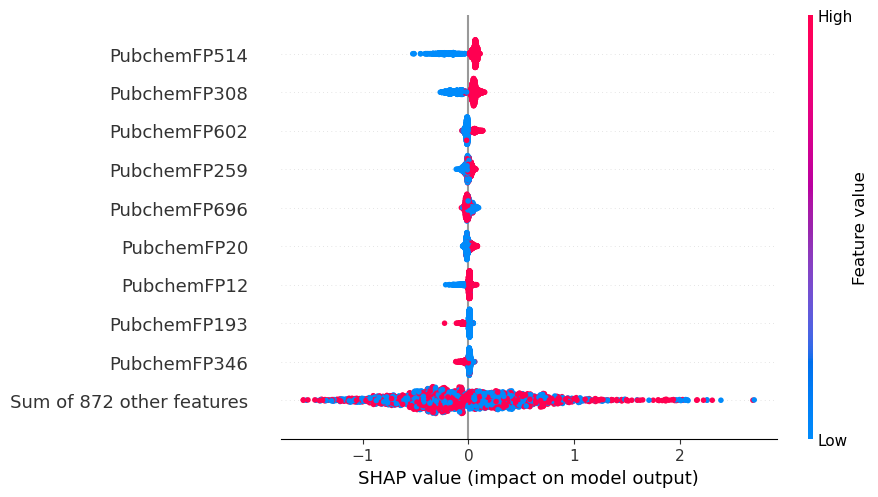

In [42]:
shap.plots.beeswarm(shap_values)

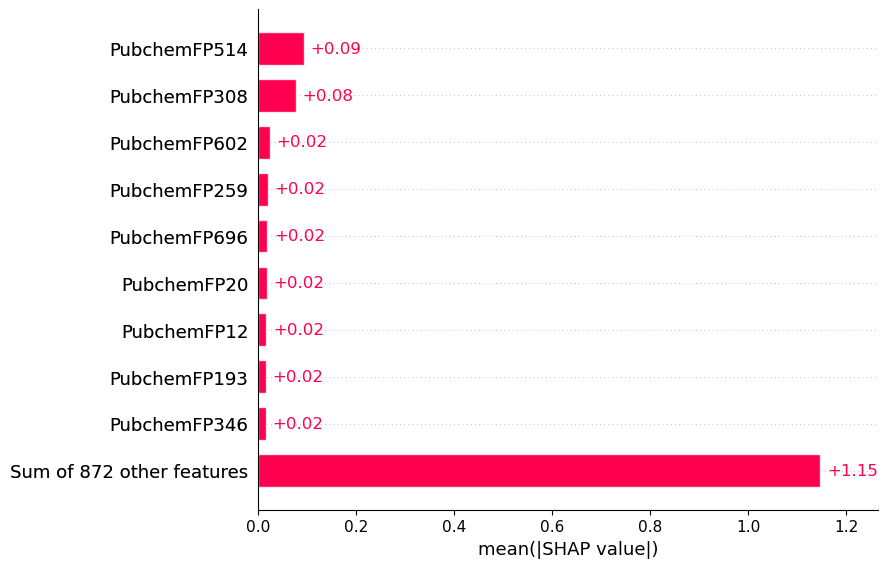

In [43]:
shap.plots.bar(shap_values)

# 11. Estimating applicability domain. Method - Euclidian distances, K=1

In [44]:
neighbors_k= pairwise_distances(x_tr, n_jobs=-1)
neighbors_k.sort(0)

In [45]:
df_tr=pd.DataFrame(neighbors_k)
df_tr

,0,1,2,3,4,5,6,7,8,9,...,2200,2201,2202,2203,2204,2205,2206,2207,2208,2209
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,4.898980,4.795832,1.414214,0.000000,4.582576,0.000000,2.000000,0.000000,3.162278,4.123106,...,2.000000,3.162278,6.782330,1.732051,3.741657,7.141428,0.000000,0.000000,2.828427,2.000000
2,5.000000,4.795832,3.464102,1.732051,4.582576,3.464102,2.000000,1.732051,3.464102,4.123106,...,3.316625,3.162278,7.071068,2.236068,6.164414,7.211102,2.449490,2.449490,3.605551,4.582576
3,5.196152,5.000000,4.358899,1.732051,4.582576,5.000000,2.236068,1.732051,3.464102,4.582576,...,6.708204,3.316625,7.280110,3.741657,6.164414,7.280110,2.449490,2.449490,4.000000,5.196152
4,5.196152,5.567764,4.358899,2.236068,4.898980,5.099020,2.236068,2.236068,3.464102,4.795832,...,6.855655,3.464102,7.615773,3.741657,6.324555,7.416198,2.645751,2.645751,4.123106,5.656854
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205,12.845233,13.490738,12.489996,12.288206,13.000000,13.379088,12.489996,12.288206,12.609520,11.789826,...,14.422205,12.922848,14.899665,13.038404,13.416408,13.416408,12.165525,12.165525,13.152946,12.806249
2206,12.845233,13.564660,12.529964,12.328828,13.000000,13.416408,12.529964,12.328828,12.649111,11.874342,...,14.422205,12.922848,14.966630,13.076696,13.453624,13.490738,12.247449,12.247449,13.152946,12.806249
2207,12.961481,13.564660,12.529964,12.409674,13.114877,13.416408,12.529964,12.409674,12.727922,12.165525,...,14.422205,13.000000,15.066519,13.453624,13.490738,13.490738,12.288206,12.288206,13.266500,12.845233
2208,13.000000,13.638182,12.649111,12.489996,13.152946,13.527749,12.688578,12.489996,13.114877,12.688578,...,14.456832,13.000000,15.132746,13.638182,13.784049,13.527749,12.922848,12.922848,13.341664,13.076696


In [46]:
similarity= neighbors_k

In [47]:
Dmean=np.mean(similarity[1,:])

In [48]:
round(Dmean, 2)

np.float32(2.57)

In [49]:
std=np.std(similarity[1,:])

In [50]:
round(std, 2)

np.float32(1.74)

In [51]:
model_AD_limit=Dmean+std*0.5
print(np.round(model_AD_limit, 2))

3.44


In [52]:
neighbors_k_ts= pairwise_distances(x_tr,Y=desc_ts, n_jobs=-1)
neighbors_k_ts.sort(0)

In [53]:
x_ts_AD=pd.DataFrame(neighbors_k_ts)
x_ts_AD

,0,1,2,3,4,5,6,7,8,9,...,543,544,545,546,547,548,549,550,551,552
0,3.000000,4.358899,2.000000,4.358899,1.414214,2.645751,5.477226,1.414214,2.236068,5.099020,...,4.000000,0.000000,0.000000,2.000000,2.828427,2.000000,2.000000,0.000000,2.828427,0.000000
1,3.162278,4.690416,2.000000,4.582576,1.414214,2.645751,5.567764,2.236068,2.236068,5.385165,...,5.196152,2.828427,2.828427,2.645751,3.000000,3.605551,2.236068,1.000000,3.872983,0.000000
2,3.162278,4.690416,3.162278,4.795832,2.236068,3.162278,5.656854,4.472136,2.236068,5.385165,...,5.477226,3.000000,3.000000,2.828427,3.316625,4.123106,2.645751,1.732051,4.242641,1.732051
3,3.605551,4.795832,3.316625,4.898979,2.236068,3.162278,6.000000,4.690416,2.236068,5.477226,...,5.477226,3.000000,3.000000,3.000000,3.316625,4.123106,2.645751,1.732051,4.358899,2.449490
4,4.000000,4.898979,3.316625,5.000000,2.645751,3.162278,6.164414,4.795832,2.236068,5.477226,...,5.656854,3.464102,3.464102,3.000000,3.316625,4.123106,2.645751,1.732051,4.472136,2.645751
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205,12.688578,12.041595,12.288206,12.609520,12.206556,12.449900,12.727922,14.282857,12.961481,13.341664,...,13.266499,13.000000,13.000000,12.845233,14.247807,12.649111,14.106736,14.000000,13.266499,13.892444
2206,12.806248,12.041595,12.449900,12.649111,12.247449,12.489996,12.767145,14.317821,12.961481,13.379088,...,13.266499,13.076697,13.076697,12.845233,14.282857,12.727922,14.142136,14.035669,13.266499,14.000000
2207,12.845233,12.083046,12.489996,12.884099,12.409674,12.529964,12.806248,14.317821,13.038405,13.379088,...,13.379088,13.190906,13.190906,12.922848,14.317821,12.727922,14.177447,14.071247,13.341664,14.142136
2208,13.152946,12.569805,13.152946,13.601471,12.489996,12.609520,12.845233,14.352700,13.601471,13.490738,...,13.416408,13.228757,13.228757,13.152946,14.352700,12.767145,14.212670,14.106736,13.564660,14.212670


In [54]:
similarity_ts= neighbors_k_ts
cpd_AD=similarity_ts[0,:]
cpd_value = np.round(cpd_AD, 3)
print(cpd_value)

[3.    4.359 2.    4.359 1.414 2.646 5.477 1.414 2.236 5.099 3.873 0.
 0.    3.606 4.    1.    2.    1.414 2.236 5.385 0.    2.    2.828 4.359
 2.236 1.732 2.236 4.359 3.162 3.464 3.    3.317 3.317 2.449 1.414 3.606
 2.646 1.732 2.646 5.196 3.873 5.568 4.243 0.    2.828 3.    1.414 1.414
 2.236 3.162 3.    4.243 3.464 1.732 1.414 2.828 1.414 7.211 0.    0.
 2.    5.099 3.317 1.    0.    2.    2.    3.464 1.414 2.236 3.742 2.646
 0.    5.196 2.236 0.    5.831 1.414 4.472 0.    1.414 0.    1.    3.
 1.    5.    3.873 0.    0.    2.236 2.    4.    1.    0.    2.449 3.464
 6.164 2.646 0.    5.745 3.742 0.    0.    1.732 2.449 5.099 4.243 3.317
 1.414 2.646 1.414 4.123 2.828 3.464 0.    4.123 1.    2.449 0.    2.236
 3.606 0.    2.236 5.385 0.    0.    2.449 1.    2.    2.449 3.464 4.583
 2.646 3.873 1.    3.317 2.236 4.796 1.414 2.236 3.317 1.732 0.    1.414
 0.    0.    1.    4.69  1.414 1.732 0.    1.414 0.    2.449 4.359 1.414
 8.602 1.414 4.    3.742 2.449 2.449 3.    2.828 3.162 5.657

In [55]:
cpd_AD = np.where(cpd_value <= model_AD_limit, True, False)
print(cpd_AD)

[ True False  True False  True  True False  True  True False False  True
  True False False  True  True  True  True False  True  True  True False
  True  True  True False  True False  True  True  True  True  True False
  True  True  True False False False False  True  True  True  True  True
  True  True  True False False  True  True  True  True False  True  True
  True False  True  True  True  True  True False  True  True False  True
  True False  True  True False  True False  True  True  True  True  True
  True False False  True  True  True  True False  True  True  True False
 False  True  True False False  True  True  True  True False False  True
  True  True  True False  True False  True False  True  True  True  True
 False  True  True False  True  True  True  True  True  True False False
  True False  True  True  True False  True  True  True  True  True  True
  True  True  True False  True  True  True  True  True  True False  True
 False  True False False  True  True  True  True  T

In [56]:
print("Coverage = ", round(sum(cpd_AD) / len(cpd_AD),2))

Coverage =  0.73


In [57]:
print("Indices of substances included in AD = ", np.where(cpd_AD != 0)[0])

Indices of substances included in AD =  [  0   2   4   5   7   8  11  12  15  16  17  18  20  21  22  24  25  26
  28  30  31  32  33  34  36  37  38  43  44  45  46  47  48  49  50  53
  54  55  56  58  59  60  62  63  64  65  66  68  69  71  72  74  75  77
  79  80  81  82  83  84  87  88  89  90  92  93  94  97  98 101 102 103
 104 107 108 109 110 112 114 116 117 118 119 121 122 124 125 126 127 128
 129 132 134 135 136 138 139 140 141 142 143 144 145 146 148 149 150 151
 152 153 155 157 160 161 162 163 164 167 169 170 171 172 173 175 176 177
 178 179 180 181 182 183 185 186 187 190 191 192 195 199 202 203 205 206
 208 209 210 211 212 213 214 216 217 218 219 221 222 224 225 226 227 228
 230 233 234 235 236 237 238 239 240 241 242 244 245 247 248 249 250 251
 252 253 255 256 258 259 260 261 262 264 265 266 267 268 269 270 273 274
 275 277 278 279 282 283 284 285 286 288 289 290 294 295 296 298 299 300
 301 303 304 305 307 308 309 310 311 312 313 314 315 316 319 320 321 322
 323 324 32

In [58]:
out_Ad=list(np.where(cpd_AD == 0)[0])

# 12. Prediction only for molecules included in  AD

In [59]:
y_pred_GBR_ad=list(y_pred_GBR)

In [60]:
y_pred_GBR_ad[:] = [x for i,x in enumerate(y_pred_GBR_ad) if i not in out_Ad]

In [61]:
len(y_pred_GBR_ad)

405

In [62]:
y_ts_ad=list(y_ts)

In [63]:
y_ts_ad[:] = [x for i,x in enumerate(y_ts_ad) if i not in out_Ad]

In [64]:
len(y_ts_ad)

405

In [65]:
Q2_TS = round(r2_score(y_ts_ad, y_pred_GBR_ad), 2)
Q2_TS

0.67

In [66]:
RMSE_TS=float(round(np.sqrt(mean_squared_error(y_ts_ad, y_pred_GBR_ad)), 2))
RMSE_TS

0.49

# SVM model building and validation

In [67]:
from sklearn.svm import SVR

In [68]:
param_grid = {"C": [10 ** i for i in range(0, 5)],
              "gamma": [10 ** i for i in range(-6, 0)]}

In [69]:
seed = 42
cv=KFold(n_splits=5, random_state=seed, shuffle=True)

In [70]:
svm = GridSearchCV(SVR(C=1.0, epsilon=0.2), param_grid, n_jobs=-1, cv=cv, verbose=1)

In [71]:
svm.fit(x_tr, y_tr)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,SVR(epsilon=0.2)
,param_grid,"{'C': [1, 10, ...], 'gamma': [1e-06, 1e-05, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'rbf'


In [72]:
svm.best_params_
best_svm = svm.best_estimator_

In [73]:
svm.best_params_

{'C': 10, 'gamma': 0.01}

In [69]:
y_pred_ws_SVM = best_svm.predict(x_tr)

In [70]:
R2_WS = round(r2_score(y_tr, y_pred_ws_SVM), 2)
R2_WS

0.87

In [71]:
RMSE_WS=float(round(np.sqrt(mean_squared_error(y_tr, y_pred_ws_SVM)), 2))
RMSE_WS

0.31

In [72]:
y_pred_CV_svm = cross_val_predict(best_svm, x_tr, y_tr, cv=cv)

In [73]:
Q2_CV = round(r2_score(y_tr, y_pred_CV_svm), 2)
Q2_CV

0.49

In [74]:
RMSE_CV=float(round(np.sqrt(mean_squared_error(y_tr, y_pred_CV_svm)), 2))
RMSE_CV

0.61

#  Prediction for test set's molecules

In [75]:
x_ts = np.array(desc_ts, dtype=np.float32)
y_ts = np.array(y_ts, dtype=np.float32)

In [76]:
y_pred_svm = best_svm.predict(x_ts)

In [77]:
Q2_TS = round(r2_score(y_ts, y_pred_svm), 2)
Q2_TS

0.53

In [78]:
RMSE_TS=float(round(np.sqrt(mean_squared_error(y_ts, y_pred_svm)), 2))
RMSE_TS

0.58

save the model to disk

In [81]:
pickle.dump(best_svm, open('Models/Padels/PubChem.pkl', 'wb'))

load the model from disk

In [67]:
best_svm = pickle.load(open('Models/Padels/PubChem.pkl', 'rb'))

# 11. Estimating applicability domain. Method - Euclidian distances, K=1

In [79]:
neighbors_k= pairwise_distances(x_tr, n_jobs=-1)
neighbors_k.sort(0)

In [80]:
df_tr=pd.DataFrame(neighbors_k)
df_tr

,0,1,2,3,4,5,6,7,8,9,...,2200,2201,2202,2203,2204,2205,2206,2207,2208,2209
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,4.898980,4.795832,1.414214,0.000000,4.582576,0.000000,2.000000,0.000000,3.162278,4.123106,...,2.000000,3.162278,6.782330,1.732051,3.741657,7.141428,0.000000,0.000000,2.828427,2.000000
2,5.000000,4.795832,3.464102,1.732051,4.582576,3.464102,2.000000,1.732051,3.464102,4.123106,...,3.316625,3.162278,7.071068,2.236068,6.164414,7.211102,2.449490,2.449490,3.605551,4.582576
3,5.196152,5.000000,4.358899,1.732051,4.582576,5.000000,2.236068,1.732051,3.464102,4.582576,...,6.708204,3.316625,7.280110,3.741657,6.164414,7.280110,2.449490,2.449490,4.000000,5.196152
4,5.196152,5.567764,4.358899,2.236068,4.898980,5.099020,2.236068,2.236068,3.464102,4.795832,...,6.855655,3.464102,7.615773,3.741657,6.324555,7.416198,2.645751,2.645751,4.123106,5.656854
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205,12.845233,13.490738,12.489996,12.288206,13.000000,13.379088,12.489996,12.288206,12.609520,11.789826,...,14.422205,12.922848,14.899665,13.038404,13.416408,13.416408,12.165525,12.165525,13.152946,12.806249
2206,12.845233,13.564660,12.529964,12.328828,13.000000,13.416408,12.529964,12.328828,12.649111,11.874342,...,14.422205,12.922848,14.966630,13.076696,13.453624,13.490738,12.247449,12.247449,13.152946,12.806249
2207,12.961481,13.564660,12.529964,12.409674,13.114877,13.416408,12.529964,12.409674,12.727922,12.165525,...,14.422205,13.000000,15.066519,13.453624,13.490738,13.490738,12.288206,12.288206,13.266500,12.845233
2208,13.000000,13.638182,12.649111,12.489996,13.152946,13.527749,12.688578,12.489996,13.114877,12.688578,...,14.456832,13.000000,15.132746,13.638182,13.784049,13.527749,12.922848,12.922848,13.341664,13.076696


In [81]:
similarity= neighbors_k

In [82]:
Dmean=np.mean(similarity[1,:])

In [83]:
round(Dmean, 2)

np.float32(2.57)

In [84]:
std=np.std(similarity[1,:])

In [85]:
round(std, 2)

np.float32(1.74)

In [86]:
model_AD_limit=Dmean+std*0.5
print(np.round(model_AD_limit, 2))

3.44


In [87]:
neighbors_k_ts= pairwise_distances(x_tr,Y=x_ts, n_jobs=-1)
neighbors_k_ts.sort(0)

In [88]:
x_ts_AD=pd.DataFrame(neighbors_k_ts)
x_ts_AD

,0,1,2,3,4,5,6,7,8,9,...,543,544,545,546,547,548,549,550,551,552
0,3.000000,4.358899,2.000000,4.358899,1.414214,2.645751,5.477226,1.414214,2.236068,5.099020,...,4.000000,0.000000,0.000000,2.000000,2.828427,2.000000,2.000000,0.000000,2.828427,0.000000
1,3.162278,4.690416,2.000000,4.582576,1.414214,2.645751,5.567764,2.236068,2.236068,5.385165,...,5.196152,2.828427,2.828427,2.645751,3.000000,3.605551,2.236068,1.000000,3.872983,0.000000
2,3.162278,4.690416,3.162278,4.795832,2.236068,3.162278,5.656854,4.472136,2.236068,5.385165,...,5.477226,3.000000,3.000000,2.828427,3.316625,4.123106,2.645751,1.732051,4.242640,1.732051
3,3.605551,4.795832,3.316625,4.898980,2.236068,3.162278,6.000000,4.690416,2.236068,5.477226,...,5.477226,3.000000,3.000000,3.000000,3.316625,4.123106,2.645751,1.732051,4.358899,2.449490
4,4.000000,4.898980,3.316625,5.000000,2.645751,3.162278,6.164414,4.795832,2.236068,5.477226,...,5.656854,3.464102,3.464102,3.000000,3.316625,4.123106,2.645751,1.732051,4.472136,2.645751
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205,12.688578,12.041595,12.288206,12.609520,12.206555,12.449900,12.727922,14.282857,12.961481,13.341664,...,13.266500,13.000000,13.000000,12.845233,14.247807,12.649111,14.106736,14.000000,13.266500,13.892444
2206,12.806249,12.041595,12.449900,12.649111,12.247449,12.489996,12.767145,14.317822,12.961481,13.379088,...,13.266500,13.076696,13.076696,12.845233,14.282857,12.727922,14.142136,14.035668,13.266500,14.000000
2207,12.845233,12.083046,12.489996,12.884099,12.409674,12.529964,12.806249,14.317822,13.038404,13.379088,...,13.379088,13.190906,13.190906,12.922848,14.317822,12.727922,14.177447,14.071247,13.341664,14.142136
2208,13.152946,12.569805,13.152946,13.601471,12.489996,12.609520,12.845233,14.352700,13.601471,13.490738,...,13.416408,13.228757,13.228757,13.152946,14.352700,12.767145,14.212670,14.106736,13.564660,14.212670


In [89]:
similarity_ts= neighbors_k_ts
cpd_AD=similarity_ts[0,:]
cpd_value = np.round(cpd_AD, 3)
print(cpd_value)

[3.    4.359 2.    4.359 1.414 2.646 5.477 1.414 2.236 5.099 3.873 0.
 0.    3.606 4.    1.    2.    1.414 2.236 5.385 0.    2.    2.828 4.359
 2.236 1.732 2.236 4.359 3.162 3.464 3.    3.317 3.317 2.449 1.414 3.606
 2.646 1.732 2.646 5.196 3.873 5.568 4.243 0.    2.828 3.    1.414 1.414
 2.236 3.162 3.    4.243 3.464 1.732 1.414 2.828 1.414 7.211 0.    0.
 2.    5.099 3.317 1.    0.    2.    2.    3.464 1.414 2.236 3.742 2.646
 0.    5.196 2.236 0.    5.831 1.414 4.472 0.    1.414 0.    1.    3.
 1.    5.    3.873 0.    0.    2.236 2.    4.    1.    0.    2.449 3.464
 6.164 2.646 0.    5.745 3.742 0.    0.    1.732 2.449 5.099 4.243 3.317
 1.414 2.646 1.414 4.123 2.828 3.464 0.    4.123 1.    2.449 0.    2.236
 3.606 0.    2.236 5.385 0.    0.    2.449 1.    2.    2.449 3.464 4.583
 2.646 3.873 1.    3.317 2.236 4.796 1.414 2.236 3.317 1.732 0.    1.414
 0.    0.    1.    4.69  1.414 1.732 0.    1.414 0.    2.449 4.359 1.414
 8.602 1.414 4.    3.742 2.449 2.449 3.    2.828 3.162 5.657

In [90]:
cpd_AD = np.where(cpd_value <= model_AD_limit, True, False)
print(cpd_AD)

[ True False  True False  True  True False  True  True False False  True
  True False False  True  True  True  True False  True  True  True False
  True  True  True False  True False  True  True  True  True  True False
  True  True  True False False False False  True  True  True  True  True
  True  True  True False False  True  True  True  True False  True  True
  True False  True  True  True  True  True False  True  True False  True
  True False  True  True False  True False  True  True  True  True  True
  True False False  True  True  True  True False  True  True  True False
 False  True  True False False  True  True  True  True False False  True
  True  True  True False  True False  True False  True  True  True  True
 False  True  True False  True  True  True  True  True  True False False
  True False  True  True  True False  True  True  True  True  True  True
  True  True  True False  True  True  True  True  True  True False  True
 False  True False False  True  True  True  True  T

In [91]:
print("Coverage = ", round(sum(cpd_AD) / len(cpd_AD), 2))

Coverage =  0.73


In [92]:
print("Indices of substances included in AD = ", np.where(cpd_AD != 0)[0])

Indices of substances included in AD =  [  0   2   4   5   7   8  11  12  15  16  17  18  20  21  22  24  25  26
  28  30  31  32  33  34  36  37  38  43  44  45  46  47  48  49  50  53
  54  55  56  58  59  60  62  63  64  65  66  68  69  71  72  74  75  77
  79  80  81  82  83  84  87  88  89  90  92  93  94  97  98 101 102 103
 104 107 108 109 110 112 114 116 117 118 119 121 122 124 125 126 127 128
 129 132 134 135 136 138 139 140 141 142 143 144 145 146 148 149 150 151
 152 153 155 157 160 161 162 163 164 167 169 170 171 172 173 175 176 177
 178 179 180 181 182 183 185 186 187 190 191 192 195 199 202 203 205 206
 208 209 210 211 212 213 214 216 217 218 219 221 222 224 225 226 227 228
 230 233 234 235 236 237 238 239 240 241 242 244 245 247 248 249 250 251
 252 253 255 256 258 259 260 261 262 264 265 266 267 268 269 270 273 274
 275 277 278 279 282 283 284 285 286 288 289 290 294 295 296 298 299 300
 301 303 304 305 307 308 309 310 311 312 313 314 315 316 319 320 321 322
 323 324 32

In [93]:
out_Ad=list(np.where(cpd_AD == 0)[0])

# 12. Prediction only for molecules included in  AD

In [94]:
y_pred_svm_ad=list(y_pred_svm)

In [95]:
y_pred_svm_ad[:] = [x for i,x in enumerate(y_pred_svm_ad) if i not in out_Ad]

In [96]:
len(y_pred_svm_ad)

405

In [97]:
y_ts_ad=list(y_ts)

In [98]:
y_ts_ad[:] = [x for i,x in enumerate(y_ts_ad) if i not in out_Ad]

In [102]:
len(y_ts_ad)

405

In [103]:
Q2_TS = round(r2_score(y_ts_ad, y_pred_svm_ad), 2)
Q2_TS

0.65

In [99]:
RMSE_TS=float(round(np.sqrt(mean_squared_error(y_ts_ad, y_pred_svm_ad)), 2))
RMSE_TS

0.51

# Multi-layer Perceptron regressor

In [105]:
from sklearn.neural_network import MLPRegressor

In [106]:
param_grid ={"hidden_layer_sizes": [(400, 300, 200, 100),(100, 100, 100), (10, 10, 10),(50,)], "activation": ["tanh", "relu"], "solver": ["lbfgs", "sgd", "adam"], "alpha": [0.00005,0.0005], 'max_iter': [1000, 2000]}

In [107]:
m = GridSearchCV(MLPRegressor(), param_grid, n_jobs=-1, cv=cv, verbose=1)

In [108]:
m.fit(x_tr, y_tr)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


,estimator,MLPRegressor()
,param_grid,"{'activation': ['tanh', 'relu'], 'alpha': [5e-05, 0.0005], 'hidden_layer_sizes': [(400, ...), (100, ...), ...], 'max_iter': [1000, 2000], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [109]:
best_MLPR = m.best_estimator_

In [101]:
y_pred_ws_best_MLPR = best_MLPR.predict(x_tr)

In [102]:
R2_WS = round(r2_score(y_tr, y_pred_ws_best_MLPR), 2)
R2_WS

0.74

In [103]:
RMSE_WS=float(round(np.sqrt(mean_squared_error(y_tr, y_pred_ws_best_MLPR)), 2))
RMSE_WS

0.43

In [110]:
y_pred_CV_MLPR = cross_val_predict(best_MLPR, x_tr, y_tr, cv=cv)

C:\Users\ovtti\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\ovtti\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\ovtti\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\ovtti\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\ovtti\anaconda3\Lib\site-packages\sklearn\neural_network\_m

In [140]:
Q2_CV = round(r2_score(y_tr, y_pred_CV_MLPR), 2)
Q2_CV

0.39

In [112]:
RMSE_CV=round(np.sqrt(mean_squared_error(y_tr, y_pred_CV_MLPR)), 2)
RMSE_CV

np.float64(0.66)

# Prediction for test set's molecules

In [104]:
y_pred_MLPR = best_MLPR.predict(x_ts)

In [114]:
Q2_TS = round(r2_score(y_ts, y_pred_MLPR), 2)
Q2_TS

0.46

In [105]:
RMSE_TS=float(round(np.sqrt(mean_squared_error(y_ts, y_pred_MLPR)), 2))
RMSE_TS

0.63

save the model to disk

In [116]:
pickle.dump(best_MLPR, open('models/Padels/MLPR_PubChem.pkl', 'wb'))

load the model from disk

In [100]:
best_MLPR = pickle.load(open('models/Padels/MLPR_PubChem.pkl', 'rb'))

#  Estimating applicability domain. Method - Euclidian distances, K=1

In [106]:
neighbors_k= pairwise_distances(x_tr, n_jobs=-1)
neighbors_k.sort(0)

In [107]:
df_tr=pd.DataFrame(neighbors_k)
df_tr

,0,1,2,3,4,5,6,7,8,9,...,2200,2201,2202,2203,2204,2205,2206,2207,2208,2209
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,4.898980,4.795832,1.414214,0.000000,4.582576,0.000000,2.000000,0.000000,3.162278,4.123106,...,2.000000,3.162278,6.782330,1.732051,3.741657,7.141428,0.000000,0.000000,2.828427,2.000000
2,5.000000,4.795832,3.464102,1.732051,4.582576,3.464102,2.000000,1.732051,3.464102,4.123106,...,3.316625,3.162278,7.071068,2.236068,6.164414,7.211102,2.449490,2.449490,3.605551,4.582576
3,5.196152,5.000000,4.358899,1.732051,4.582576,5.000000,2.236068,1.732051,3.464102,4.582576,...,6.708204,3.316625,7.280110,3.741657,6.164414,7.280110,2.449490,2.449490,4.000000,5.196152
4,5.196152,5.567764,4.358899,2.236068,4.898980,5.099020,2.236068,2.236068,3.464102,4.795832,...,6.855655,3.464102,7.615773,3.741657,6.324555,7.416198,2.645751,2.645751,4.123106,5.656854
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205,12.845233,13.490738,12.489996,12.288206,13.000000,13.379088,12.489996,12.288206,12.609520,11.789826,...,14.422205,12.922848,14.899665,13.038404,13.416408,13.416408,12.165525,12.165525,13.152946,12.806249
2206,12.845233,13.564660,12.529964,12.328828,13.000000,13.416408,12.529964,12.328828,12.649111,11.874342,...,14.422205,12.922848,14.966630,13.076696,13.453624,13.490738,12.247449,12.247449,13.152946,12.806249
2207,12.961481,13.564660,12.529964,12.409674,13.114877,13.416408,12.529964,12.409674,12.727922,12.165525,...,14.422205,13.000000,15.066519,13.453624,13.490738,13.490738,12.288206,12.288206,13.266500,12.845233
2208,13.000000,13.638182,12.649111,12.489996,13.152946,13.527749,12.688578,12.489996,13.114877,12.688578,...,14.456832,13.000000,15.132746,13.638182,13.784049,13.527749,12.922848,12.922848,13.341664,13.076696


In [108]:
similarity= neighbors_k

In [109]:
Dmean=np.mean(similarity[1,:])

In [110]:
round(Dmean, 2)

np.float32(2.57)

In [111]:
std=np.std(similarity[1,:])

In [112]:
round(std, 2)

np.float32(1.74)

In [113]:
model_AD_limit=Dmean+std*0.5
print(np.round(model_AD_limit, 2))

3.44


In [114]:
neighbors_k_ts= pairwise_distances(x_tr,Y=x_ts, n_jobs=-1)
neighbors_k_ts.sort(0)

In [115]:
x_ts_AD=pd.DataFrame(neighbors_k_ts)
x_ts_AD

,0,1,2,3,4,5,6,7,8,9,...,543,544,545,546,547,548,549,550,551,552
0,3.000000,4.358899,2.000000,4.358899,1.414214,2.645751,5.477226,1.414214,2.236068,5.099020,...,4.000000,0.000000,0.000000,2.000000,2.828427,2.000000,2.000000,0.000000,2.828427,0.000000
1,3.162278,4.690416,2.000000,4.582576,1.414214,2.645751,5.567764,2.236068,2.236068,5.385165,...,5.196152,2.828427,2.828427,2.645751,3.000000,3.605551,2.236068,1.000000,3.872983,0.000000
2,3.162278,4.690416,3.162278,4.795832,2.236068,3.162278,5.656854,4.472136,2.236068,5.385165,...,5.477226,3.000000,3.000000,2.828427,3.316625,4.123106,2.645751,1.732051,4.242640,1.732051
3,3.605551,4.795832,3.316625,4.898980,2.236068,3.162278,6.000000,4.690416,2.236068,5.477226,...,5.477226,3.000000,3.000000,3.000000,3.316625,4.123106,2.645751,1.732051,4.358899,2.449490
4,4.000000,4.898980,3.316625,5.000000,2.645751,3.162278,6.164414,4.795832,2.236068,5.477226,...,5.656854,3.464102,3.464102,3.000000,3.316625,4.123106,2.645751,1.732051,4.472136,2.645751
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205,12.688578,12.041595,12.288206,12.609520,12.206555,12.449900,12.727922,14.282857,12.961481,13.341664,...,13.266500,13.000000,13.000000,12.845233,14.247807,12.649111,14.106736,14.000000,13.266500,13.892444
2206,12.806249,12.041595,12.449900,12.649111,12.247449,12.489996,12.767145,14.317822,12.961481,13.379088,...,13.266500,13.076696,13.076696,12.845233,14.282857,12.727922,14.142136,14.035668,13.266500,14.000000
2207,12.845233,12.083046,12.489996,12.884099,12.409674,12.529964,12.806249,14.317822,13.038404,13.379088,...,13.379088,13.190906,13.190906,12.922848,14.317822,12.727922,14.177447,14.071247,13.341664,14.142136
2208,13.152946,12.569805,13.152946,13.601471,12.489996,12.609520,12.845233,14.352700,13.601471,13.490738,...,13.416408,13.228757,13.228757,13.152946,14.352700,12.767145,14.212670,14.106736,13.564660,14.212670


In [116]:
similarity_ts= neighbors_k_ts
cpd_AD=similarity_ts[0,:]
cpd_value = np.round(cpd_AD, 3)
print(cpd_value)

[3.    4.359 2.    4.359 1.414 2.646 5.477 1.414 2.236 5.099 3.873 0.
 0.    3.606 4.    1.    2.    1.414 2.236 5.385 0.    2.    2.828 4.359
 2.236 1.732 2.236 4.359 3.162 3.464 3.    3.317 3.317 2.449 1.414 3.606
 2.646 1.732 2.646 5.196 3.873 5.568 4.243 0.    2.828 3.    1.414 1.414
 2.236 3.162 3.    4.243 3.464 1.732 1.414 2.828 1.414 7.211 0.    0.
 2.    5.099 3.317 1.    0.    2.    2.    3.464 1.414 2.236 3.742 2.646
 0.    5.196 2.236 0.    5.831 1.414 4.472 0.    1.414 0.    1.    3.
 1.    5.    3.873 0.    0.    2.236 2.    4.    1.    0.    2.449 3.464
 6.164 2.646 0.    5.745 3.742 0.    0.    1.732 2.449 5.099 4.243 3.317
 1.414 2.646 1.414 4.123 2.828 3.464 0.    4.123 1.    2.449 0.    2.236
 3.606 0.    2.236 5.385 0.    0.    2.449 1.    2.    2.449 3.464 4.583
 2.646 3.873 1.    3.317 2.236 4.796 1.414 2.236 3.317 1.732 0.    1.414
 0.    0.    1.    4.69  1.414 1.732 0.    1.414 0.    2.449 4.359 1.414
 8.602 1.414 4.    3.742 2.449 2.449 3.    2.828 3.162 5.657

In [117]:
cpd_AD = np.where(cpd_value <= model_AD_limit, True, False)
print(cpd_AD)

[ True False  True False  True  True False  True  True False False  True
  True False False  True  True  True  True False  True  True  True False
  True  True  True False  True False  True  True  True  True  True False
  True  True  True False False False False  True  True  True  True  True
  True  True  True False False  True  True  True  True False  True  True
  True False  True  True  True  True  True False  True  True False  True
  True False  True  True False  True False  True  True  True  True  True
  True False False  True  True  True  True False  True  True  True False
 False  True  True False False  True  True  True  True False False  True
  True  True  True False  True False  True False  True  True  True  True
 False  True  True False  True  True  True  True  True  True False False
  True False  True  True  True False  True  True  True  True  True  True
  True  True  True False  True  True  True  True  True  True False  True
 False  True False False  True  True  True  True  T

In [118]:
print("Coverage = ", round(sum(cpd_AD) / len(cpd_AD), 2))

Coverage =  0.73


In [119]:
print("Indices of substances included in AD = ", np.where(cpd_AD != 0)[0])

Indices of substances included in AD =  [  0   2   4   5   7   8  11  12  15  16  17  18  20  21  22  24  25  26
  28  30  31  32  33  34  36  37  38  43  44  45  46  47  48  49  50  53
  54  55  56  58  59  60  62  63  64  65  66  68  69  71  72  74  75  77
  79  80  81  82  83  84  87  88  89  90  92  93  94  97  98 101 102 103
 104 107 108 109 110 112 114 116 117 118 119 121 122 124 125 126 127 128
 129 132 134 135 136 138 139 140 141 142 143 144 145 146 148 149 150 151
 152 153 155 157 160 161 162 163 164 167 169 170 171 172 173 175 176 177
 178 179 180 181 182 183 185 186 187 190 191 192 195 199 202 203 205 206
 208 209 210 211 212 213 214 216 217 218 219 221 222 224 225 226 227 228
 230 233 234 235 236 237 238 239 240 241 242 244 245 247 248 249 250 251
 252 253 255 256 258 259 260 261 262 264 265 266 267 268 269 270 273 274
 275 277 278 279 282 283 284 285 286 288 289 290 294 295 296 298 299 300
 301 303 304 305 307 308 309 310 311 312 313 314 315 316 319 320 321 322
 323 324 32

In [120]:
out_Ad=list(np.where(cpd_AD == 0)[0])

# Prediction only for molecules included in  AD

In [121]:
y_pred_MLPR_ad=list(y_pred_MLPR)

In [122]:
y_pred_MLPR_ad[:] = [x for i,x in enumerate(y_pred_MLPR_ad) if i not in out_Ad]

In [123]:
len(y_pred_MLPR_ad)

405

In [124]:
y_ts_ad=list(y_ts)

In [125]:
y_ts_ad[:] = [x for i,x in enumerate(y_ts_ad) if i not in out_Ad]

In [126]:
len(y_ts_ad)

405

In [127]:
Q2_TS = round(r2_score(y_ts_ad, y_pred_MLPR_ad), 2)
Q2_TS

0.54

In [128]:
RMSE_TS=float(round(np.sqrt(mean_squared_error(y_ts_ad, y_pred_MLPR_ad)), 2))
RMSE_TS

0.58

# k-nearest neighbors

In [157]:
k_range = list(range(1, 31))
param_grid = dict(n_neighbors=k_range)

In [158]:
m = GridSearchCV(KNeighborsRegressor(), param_grid, n_jobs=-1, cv=cv, verbose=1)

In [159]:
m.fit(x_tr, y_tr)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,KNeighborsRegressor()
,param_grid,"{'n_neighbors': [1, 2, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,6


In [160]:
best_kNN = m.best_estimator_

In [161]:
m.best_params_

{'n_neighbors': 6}

In [162]:
y_pred_ws_kNN = best_kNN.predict(x_tr)

In [163]:
R2_WS = round(r2_score(y_tr, y_pred_ws_kNN), 2)
R2_WS

0.61

In [164]:
RMSE_WS=float(round(np.sqrt(mean_squared_error(y_tr, y_pred_ws_kNN)), 2))
RMSE_WS

0.53

In [165]:
y_pred_CV_kNN = cross_val_predict(best_kNN, x_tr, y_tr, cv=cv)

In [166]:
y_pred_CV_kNN

array([6.5983334, 5.7966666, 5.046666 , ..., 7.1716666, 6.5499997,
       7.0950007], shape=(2210,), dtype=float32)

In [167]:
Q2_CV = round(r2_score(y_tr, y_pred_CV_kNN), 2)
Q2_CV

0.43

In [143]:
RMSE_CV=float(round(np.sqrt(mean_squared_error(y_tr, y_pred_CV_kNN)), 2))
RMSE_CV

0.64

# 9. Prediction for test set's molecules

In [174]:
y_pred_kNN = best_kNN.predict(x_ts)

C:\Users\ovtti\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(


In [175]:
Q2_TS = round(r2_score(y_ts, y_pred_kNN), 2)
Q2_TS

0.45

In [176]:
RMSE_TS=float(round(np.sqrt(mean_squared_error(y_ts, y_pred_kNN)), 2))
RMSE_TS

0.63

# save the model to disk

In [177]:
pickle.dump(best_kNN, open('models/Padels/PubChem_kNN.pkl', 'wb'))

# load the model from disk

In [146]:
best_kNN = pickle.load(open('models/Padels/PubChem_kNN.pkl', 'rb'))

#  Estimating applicability domain. Method - Euclidian distances, K=1

In [178]:
neighbors_k= pairwise_distances(x_tr, n_jobs=-1)
neighbors_k.sort(0)

In [179]:
df_tr=pd.DataFrame(neighbors_k)
df_tr

,0,1,2,3,4,5,6,7,8,9,...,2200,2201,2202,2203,2204,2205,2206,2207,2208,2209
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,4.898980,4.795832,1.414214,0.000000,4.582576,0.000000,2.000000,0.000000,3.162278,4.123106,...,2.000000,3.162278,6.782330,1.732051,3.741657,7.141428,0.000000,0.000000,2.828427,2.000000
2,5.000000,4.795832,3.464102,1.732051,4.582576,3.464102,2.000000,1.732051,3.464102,4.123106,...,3.316625,3.162278,7.071068,2.236068,6.164414,7.211102,2.449490,2.449490,3.605551,4.582576
3,5.196152,5.000000,4.358899,1.732051,4.582576,5.000000,2.236068,1.732051,3.464102,4.582576,...,6.708204,3.316625,7.280110,3.741657,6.164414,7.280110,2.449490,2.449490,4.000000,5.196152
4,5.196152,5.567764,4.358899,2.236068,4.898980,5.099020,2.236068,2.236068,3.464102,4.795832,...,6.855655,3.464102,7.615773,3.741657,6.324555,7.416198,2.645751,2.645751,4.123106,5.656854
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205,12.845233,13.490738,12.489996,12.288206,13.000000,13.379088,12.489996,12.288206,12.609520,11.789826,...,14.422205,12.922848,14.899665,13.038404,13.416408,13.416408,12.165525,12.165525,13.152946,12.806249
2206,12.845233,13.564660,12.529964,12.328828,13.000000,13.416408,12.529964,12.328828,12.649111,11.874342,...,14.422205,12.922848,14.966630,13.076696,13.453624,13.490738,12.247449,12.247449,13.152946,12.806249
2207,12.961481,13.564660,12.529964,12.409674,13.114877,13.416408,12.529964,12.409674,12.727922,12.165525,...,14.422205,13.000000,15.066519,13.453624,13.490738,13.490738,12.288206,12.288206,13.266500,12.845233
2208,13.000000,13.638182,12.649111,12.489996,13.152946,13.527749,12.688578,12.489996,13.114877,12.688578,...,14.456832,13.000000,15.132746,13.638182,13.784049,13.527749,12.922848,12.922848,13.341664,13.076696


In [180]:
similarity= neighbors_k

In [181]:
Dmean=np.mean(similarity[1,:])

In [182]:
round(Dmean, 2)

np.float32(2.57)

In [183]:
std=np.std(similarity[1,:])

In [184]:
round(std, 2)

np.float32(1.74)

In [185]:
model_AD_limit=Dmean+std*0.5
print(np.round(model_AD_limit, 2))

3.44


In [187]:
neighbors_k_ts= pairwise_distances(x_tr,Y=desc_ts, n_jobs=-1)
neighbors_k_ts.sort(0)

In [188]:
x_ts_AD=pd.DataFrame(neighbors_k_ts)
x_ts_AD

,0,1,2,3,4,5,6,7,8,9,...,543,544,545,546,547,548,549,550,551,552
0,3.000000,4.358899,2.000000,4.358899,1.414214,2.645751,5.477226,1.414214,2.236068,5.099020,...,4.000000,0.000000,0.000000,2.000000,2.828427,2.000000,2.000000,0.000000,2.828427,0.000000
1,3.162278,4.690416,2.000000,4.582576,1.414214,2.645751,5.567764,2.236068,2.236068,5.385165,...,5.196152,2.828427,2.828427,2.645751,3.000000,3.605551,2.236068,1.000000,3.872983,0.000000
2,3.162278,4.690416,3.162278,4.795832,2.236068,3.162278,5.656854,4.472136,2.236068,5.385165,...,5.477226,3.000000,3.000000,2.828427,3.316625,4.123106,2.645751,1.732051,4.242641,1.732051
3,3.605551,4.795832,3.316625,4.898979,2.236068,3.162278,6.000000,4.690416,2.236068,5.477226,...,5.477226,3.000000,3.000000,3.000000,3.316625,4.123106,2.645751,1.732051,4.358899,2.449490
4,4.000000,4.898979,3.316625,5.000000,2.645751,3.162278,6.164414,4.795832,2.236068,5.477226,...,5.656854,3.464102,3.464102,3.000000,3.316625,4.123106,2.645751,1.732051,4.472136,2.645751
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205,12.688578,12.041595,12.288206,12.609520,12.206556,12.449900,12.727922,14.282857,12.961481,13.341664,...,13.266499,13.000000,13.000000,12.845233,14.247807,12.649111,14.106736,14.000000,13.266499,13.892444
2206,12.806248,12.041595,12.449900,12.649111,12.247449,12.489996,12.767145,14.317821,12.961481,13.379088,...,13.266499,13.076697,13.076697,12.845233,14.282857,12.727922,14.142136,14.035669,13.266499,14.000000
2207,12.845233,12.083046,12.489996,12.884099,12.409674,12.529964,12.806248,14.317821,13.038405,13.379088,...,13.379088,13.190906,13.190906,12.922848,14.317821,12.727922,14.177447,14.071247,13.341664,14.142136
2208,13.152946,12.569805,13.152946,13.601471,12.489996,12.609520,12.845233,14.352700,13.601471,13.490738,...,13.416408,13.228757,13.228757,13.152946,14.352700,12.767145,14.212670,14.106736,13.564660,14.212670


In [189]:
similarity_ts= neighbors_k_ts
cpd_AD=similarity_ts[0,:]
cpd_value = np.round(cpd_AD, 3)
print(cpd_value)

[3.    4.359 2.    4.359 1.414 2.646 5.477 1.414 2.236 5.099 3.873 0.
 0.    3.606 4.    1.    2.    1.414 2.236 5.385 0.    2.    2.828 4.359
 2.236 1.732 2.236 4.359 3.162 3.464 3.    3.317 3.317 2.449 1.414 3.606
 2.646 1.732 2.646 5.196 3.873 5.568 4.243 0.    2.828 3.    1.414 1.414
 2.236 3.162 3.    4.243 3.464 1.732 1.414 2.828 1.414 7.211 0.    0.
 2.    5.099 3.317 1.    0.    2.    2.    3.464 1.414 2.236 3.742 2.646
 0.    5.196 2.236 0.    5.831 1.414 4.472 0.    1.414 0.    1.    3.
 1.    5.    3.873 0.    0.    2.236 2.    4.    1.    0.    2.449 3.464
 6.164 2.646 0.    5.745 3.742 0.    0.    1.732 2.449 5.099 4.243 3.317
 1.414 2.646 1.414 4.123 2.828 3.464 0.    4.123 1.    2.449 0.    2.236
 3.606 0.    2.236 5.385 0.    0.    2.449 1.    2.    2.449 3.464 4.583
 2.646 3.873 1.    3.317 2.236 4.796 1.414 2.236 3.317 1.732 0.    1.414
 0.    0.    1.    4.69  1.414 1.732 0.    1.414 0.    2.449 4.359 1.414
 8.602 1.414 4.    3.742 2.449 2.449 3.    2.828 3.162 5.657

In [190]:
cpd_AD = np.where(cpd_value <= model_AD_limit, True, False)
print(cpd_AD)

[ True False  True False  True  True False  True  True False False  True
  True False False  True  True  True  True False  True  True  True False
  True  True  True False  True False  True  True  True  True  True False
  True  True  True False False False False  True  True  True  True  True
  True  True  True False False  True  True  True  True False  True  True
  True False  True  True  True  True  True False  True  True False  True
  True False  True  True False  True False  True  True  True  True  True
  True False False  True  True  True  True False  True  True  True False
 False  True  True False False  True  True  True  True False False  True
  True  True  True False  True False  True False  True  True  True  True
 False  True  True False  True  True  True  True  True  True False False
  True False  True  True  True False  True  True  True  True  True  True
  True  True  True False  True  True  True  True  True  True False  True
 False  True False False  True  True  True  True  T

In [191]:
print("Coverage = ", round(sum(cpd_AD) / len(cpd_AD), 2))

Coverage =  0.73


In [192]:
print("Indices of substances included in AD = ", np.where(cpd_AD != 0)[0])

Indices of substances included in AD =  [  0   2   4   5   7   8  11  12  15  16  17  18  20  21  22  24  25  26
  28  30  31  32  33  34  36  37  38  43  44  45  46  47  48  49  50  53
  54  55  56  58  59  60  62  63  64  65  66  68  69  71  72  74  75  77
  79  80  81  82  83  84  87  88  89  90  92  93  94  97  98 101 102 103
 104 107 108 109 110 112 114 116 117 118 119 121 122 124 125 126 127 128
 129 132 134 135 136 138 139 140 141 142 143 144 145 146 148 149 150 151
 152 153 155 157 160 161 162 163 164 167 169 170 171 172 173 175 176 177
 178 179 180 181 182 183 185 186 187 190 191 192 195 199 202 203 205 206
 208 209 210 211 212 213 214 216 217 218 219 221 222 224 225 226 227 228
 230 233 234 235 236 237 238 239 240 241 242 244 245 247 248 249 250 251
 252 253 255 256 258 259 260 261 262 264 265 266 267 268 269 270 273 274
 275 277 278 279 282 283 284 285 286 288 289 290 294 295 296 298 299 300
 301 303 304 305 307 308 309 310 311 312 313 314 315 316 319 320 321 322
 323 324 32

In [193]:
out_Ad=list(np.where(cpd_AD == 0)[0])

# Prediction only for molecules included in  AD

In [194]:
y_pred_kNN_ad=list(y_pred_kNN)

In [195]:
y_pred_kNN_ad[:] = [x for i,x in enumerate(y_pred_kNN_ad) if i not in out_Ad]

In [196]:
len(y_pred_kNN_ad)

405

In [197]:
y_ts_ad=list(y_ts)

In [198]:
y_ts_ad[:] = [x for i,x in enumerate(y_ts_ad) if i not in out_Ad]

In [199]:
len(y_ts_ad)

405

In [200]:
Q2_TS = round(r2_score(y_ts_ad, y_pred_kNN_ad), 2)
Q2_TS

0.59

In [201]:
RMSE_TS=float(round(np.sqrt(mean_squared_error(y_ts_ad, y_pred_kNN_ad)), 2))
RMSE_TS

0.55